In [1]:
# 필수 패키지 임포트
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

# SMOTE와 Pipeline (Data Leakage 방지용)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

In [2]:
# 1. 데이터 로드
url = "https://raw.githubusercontent.com/kzming2007/UR3_Cobot_ML/refs/heads/main/dataset/ur3_cobotops.csv"
df = pd.read_csv(url)

## Decision Tree

### Cell 1: 데이터 로드 및 Feature Engineering

In [3]:
df.columns = df.columns.str.strip()
df.rename(columns={'Temperature_T0': 'Temperature_J0'}, inplace=True)

# 2. 결측치 없는 클린 데이터 분리
df_clean = df.dropna().copy()

# 3. 파생 변수 생성 (Power = Current * Speed 등)
current_cols = [f'Current_J{i}' for i in range(6)]
speed_cols = [f'Speed_J{i}' for i in range(6)]
temp_cols = [f'Temperature_J{i}' for i in range(6)]
for i in range(6):
    df_clean[f'Power_J{i}'] = df_clean[f'Current_J{i}'] * df_clean[f'Speed_J{i}']

df_clean['Total_Power_Electric'] = (df_clean[current_cols]**2).sum(axis=1)

# 4. 입력 피처(X) 설정
input_cols = current_cols + speed_cols + temp_cols + ['Tool_current'] + [f'Power_J{i}' for i in range(6)] + ['Total_Power_Electric']
X = df_clean[input_cols]

print(f"데이터 크기: {df_clean.shape}")
print(f"피처 개수: {len(input_cols)}개")

데이터 크기: (7355, 31)
피처 개수: 26개


### Cell 2: 타겟 변수 라벨링

In [4]:
# 통합 이진 타겟(System_Failure) 생성: Protective Stop 또는 Grip Lost 발생 시 1
df_clean['Robot_ProtectiveStop'] = df_clean['Robot_ProtectiveStop'].astype(bool).astype(int)
df_clean['grip_lost'] = df_clean['grip_lost'].astype(bool).astype(int)

y = ((df_clean['Robot_ProtectiveStop'] == 1) | (df_clean['grip_lost'] == 1)).astype(int)

print("분류된 타겟(y)의 클래스별 데이터 개수:")
print(y.value_counts().sort_index())
# 0: Normal(정상), 1: Failure(고장)

분류된 타겟(y)의 클래스별 데이터 개수:
0    6837
1     518
Name: count, dtype: int64


### Cell 3: 데이터 분할 및 스케일링

In [5]:
# 1. Train / Test Split (클래스 비율을 유지하기 위해 stratify=y 적용)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 결정 트리(Tree 기반 모델)는 거리 기반 알고리즘이 아니므로 스케일링이 필수는 아닙니다.
# 따라서 스케일링 단계는 생략하고 원본 데이터를 그대로 사용합니다.

print(f"학습 데이터 크기: {X_train.shape}")
print(f"테스트 데이터 크기: {X_test.shape}")

학습 데이터 크기: (5884, 26)
테스트 데이터 크기: (1471, 26)


### Cell 4: Decision Tree 학습 및 하이퍼파라미터 튜닝

In [6]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Imblearn Pipeline 구축
pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('dt', DecisionTreeClassifier(random_state=42, class_weight='balanced'))
])

# 파라미터 그리드 (트리 깊이 및 분할 조건 탐색)
param_grid = {
    'dt__criterion': ['gini', 'entropy'],
    'dt__max_depth': [7, 10, 15],
    'dt__min_samples_leaf': [7, 10, 15],
    'dt__min_samples_split': [5, 10, 15, 20]
}

print("--- Decision Tree 하이퍼파라미터 탐색 및 5-Fold 교차 검증 진행 중 ---")
grid_search = GridSearchCV(
    estimator=pipeline, 
    param_grid=param_grid, 
    cv=skf, 
    scoring='f1_macro', 
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("\n[GridSearchCV 결과]")
print("[최적의 하이퍼파라미터 설정]")
for param, value in grid_search.best_params_.items():
    print(f"  • {param.replace('dt__', '')}: {value}")
print("")
print(f"최고 교차 검증 F1-Macro 점수: {grid_search.best_score_:.4f}")

--- Decision Tree 하이퍼파라미터 탐색 및 5-Fold 교차 검증 진행 중 ---
Fitting 5 folds for each of 72 candidates, totalling 360 fits

[GridSearchCV 결과]
[최적의 하이퍼파라미터 설정]
  • criterion: entropy
  • max_depth: 15
  • min_samples_leaf: 7
  • min_samples_split: 15

최고 교차 검증 F1-Macro 점수: 0.6805


### Cell 5: 상위 10개 모델 비교 데이터프레임 & 최종 평가

In [7]:
# 1. GridSearchCV 결과에서 상위 10개 모델 추출
cv_results_df = pd.DataFrame(grid_search.cv_results_)
top_models = cv_results_df.sort_values('rank_test_score').head(10)

# 비교 결과를 담을 리스트
comparison_data = []
print("--- [모델 비교] 상위 10개 Decision Tree 성능 종합 ---")

# 2. 상위 모델들을 하나씩 돌려가며 Train/Test 평가 진행
for index, row in top_models.iterrows():
    params = row['params']
    rank = int(row['rank_test_score'])
    cv_f1 = row['mean_test_score']
    
    # 해당 파라미터로 재학습
    model = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('dt', DecisionTreeClassifier(
            criterion=params.get('dt__criterion', 'gini'),
            max_depth=params.get('dt__max_depth', None),
            min_samples_leaf=params.get('dt__min_samples_leaf', 1),
            min_samples_split=params.get('dt__min_samples_split', 2),
            random_state=42, class_weight='balanced'
        ))
    ])
    model.fit(X_train, y_train)
    
    # 예측
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # ROC-AUC를 계산하기 위한 확률(Probability) 예측
    y_test_prob = model.predict_proba(X_test)[:, 1]

    # 평가지표 계산
    train_f1 = f1_score(y_train, y_train_pred, average='macro')
    test_f1 = f1_score(y_test, y_test_pred, average='macro')
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    # ROC-AUC 점수 계산
    test_roc_auc = roc_auc_score(y_test, y_test_prob)

    # 파라미터 설정을 간소화된 문자열로 변환 (예: C=gin, D=10, L=5, S=10)
    crit_val = params.get('dt__criterion', '-')
    depth_val = params.get('dt__max_depth', '-')
    leaf_val = params.get('dt__min_samples_leaf', '-')
    split_val = params.get('dt__min_samples_split', '-')
    param_short = f"C={str(crit_val)[:3]}, D={depth_val}, L={leaf_val}, S={split_val}"
    
    # 결과 저장
    comparison_data.append({
        '순위': rank,
        'CV F1': round(cv_f1, 4),
        'Train F1': round(train_f1, 4),
        'Test F1': round(test_f1, 4),
        '과적합 Gap': round(train_f1 - test_f1, 4), 
        'Train Acc': round(train_acc, 6),
        'Test Acc': round(test_acc, 6),
        'Test ROC-AUC': round(test_roc_auc, 6),
        '파라미터 설정': param_short
    })

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

--- [모델 비교] 상위 10개 Decision Tree 성능 종합 ---


,순위,CV F1,Train F1,Test F1,과적합 Gap,Train Acc,Test Acc,Test ROC-AUC,파라미터 설정
0,1,0.6805,0.8458,0.7022,0.1436,0.950034,0.899388,0.811610,"C=ent, D=15, L=7, S=15"
1,2,0.6794,0.8494,0.7071,0.1424,0.951394,0.900068,0.821581,"C=ent, D=15, L=7, S=5"
2,2,0.6794,0.8494,0.7071,0.1424,0.951394,0.900068,0.821581,"C=ent, D=15, L=7, S=10"
3,4,0.6740,0.8276,0.6921,0.1355,0.942386,0.892590,0.823930,"C=ent, D=15, L=7, S=20"
4,5,0.6650,0.8284,0.7040,0.1245,0.942896,0.898029,0.829684,"C=ent, D=15, L=10, S=20"
5,5,0.6650,0.8284,0.7040,0.1245,0.942896,0.898029,0.829684,"C=ent, D=15, L=10, S=15"
6,5,0.6650,0.8284,0.7040,0.1245,0.942896,0.898029,0.829684,"C=ent, D=15, L=10, S=10"
7,5,0.6650,0.8284,0.7040,0.1245,0.942896,0.898029,0.829684,"C=ent, D=15, L=10, S=5"
8,9,0.6609,0.7760,0.6749,0.1010,0.914684,0.867437,0.826691,"C=gin, D=15, L=7, S=15"
9,10,0.6596,0.7778,0.6782,0.0996,0.915024,0.867437,0.824359,"C=gin, D=15, L=7, S=5"


### Cell 6: 특정 순위 모델 최종 평가지표 상세 분석

In [8]:
print("\n" + "="*50)
target_rank = 2  # 1위 모델 상세 분석
print(f"--- [상세 분석] {target_rank}위 모델 최종 평가지표 ---")
print("="*50)

selected_row = top_models[top_models['rank_test_score'] == target_rank].iloc[0]
selected_params = selected_row['params']

print(f"\n[선택된 {target_rank}위 모델의 하이퍼파라미터]")
for param, value in selected_params.items():
    print(f"  • {param.replace('dt__', '')}: {value}")

# 재학습 모델 정의
selected_model = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('dt', DecisionTreeClassifier(
        criterion=selected_params.get('dt__criterion', 'gini'),
        max_depth=selected_params.get('dt__max_depth', None),
        min_samples_leaf=selected_params.get('dt__min_samples_leaf', 1),
        min_samples_split=selected_params.get('dt__min_samples_split', 2),
        random_state=42, class_weight='balanced'
    ))
])
selected_model.fit(X_train, y_train)

# 예측 클래스 및 확률 계산
y_train_pred_selected = selected_model.predict(X_train)
y_train_prob_selected = selected_model.predict_proba(X_train)[:, 1]

y_test_pred_selected = selected_model.predict(X_test)
y_test_prob_selected = selected_model.predict_proba(X_test)[:, 1]

# 평가지표 출력 함수
def print_metrics(y_true, y_pred, y_prob, dataset_name):
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro')
    roc_auc = roc_auc_score(y_true, y_prob)
    
    print(f"\n[{dataset_name} 데이터 평가]")
    print(f"Accuracy (정확도) : {acc:.4f}")
    print(f"F1-Macro Score    : {f1_macro:.6f}")
    print(f"ROC-AUC Score     : {roc_auc:.6f}")
    print(f"\n[{dataset_name} 상세 분류 리포트]")
    print(classification_report(y_true, y_pred, target_names=['0 (Normal)', '1 (Failure)']))

print_metrics(y_train, y_train_pred_selected, y_train_prob_selected, "Train")
print_metrics(y_test, y_test_pred_selected, y_test_prob_selected, "Test")

y_test_pred = y_test_pred_selected


--- [상세 분석] 2위 모델 최종 평가지표 ---

[선택된 2위 모델의 하이퍼파라미터]
  • criterion: entropy
  • max_depth: 15
  • min_samples_leaf: 7
  • min_samples_split: 5

[Train 데이터 평가]
Accuracy (정확도) : 0.9514
F1-Macro Score    : 0.849432
ROC-AUC Score     : 0.988685

[Train 상세 분류 리포트]
              precision    recall  f1-score   support

  0 (Normal)       0.99      0.95      0.97      5470
 1 (Failure)       0.60      0.91      0.73       414

    accuracy                           0.95      5884
   macro avg       0.80      0.93      0.85      5884
weighted avg       0.97      0.95      0.96      5884


[Test 데이터 평가]
Accuracy (정확도) : 0.9001
F1-Macro Score    : 0.707077
ROC-AUC Score     : 0.821581

[Test 상세 분류 리포트]
              precision    recall  f1-score   support

  0 (Normal)       0.97      0.92      0.94      1367
 1 (Failure)       0.38      0.62      0.47       104

    accuracy                           0.90      1471
   macro avg       0.67      0.77      0.71      1471
weighted avg       0.93   

### Cell 7: 오차 행렬(Confusion Matrix) 시각화

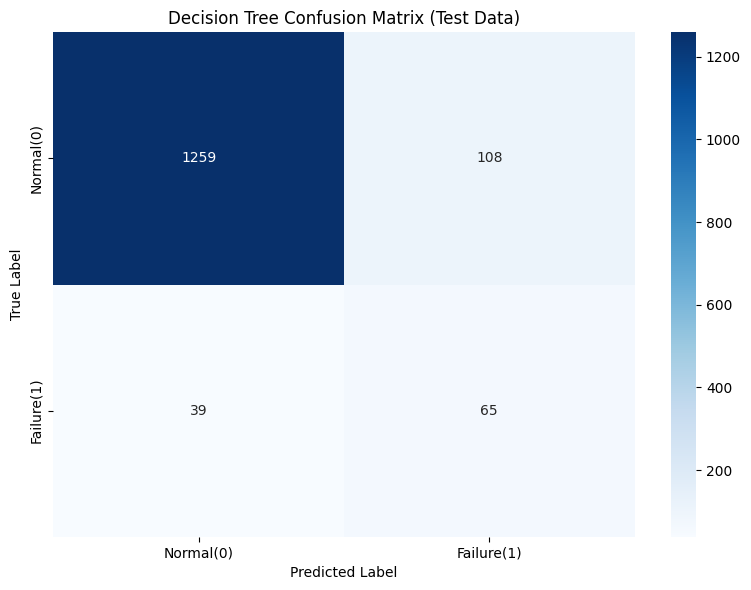

In [9]:
plt.figure(figsize=(8, 6))

cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', 
            xticklabels=['Normal(0)', 'Failure(1)'], yticklabels=['Normal(0)', 'Failure(1)'])
plt.title('Decision Tree Confusion Matrix (Test Data)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.tight_layout()
plt.show()

### Cell 8: 피처 중요도 (Feature Importance) 시각화

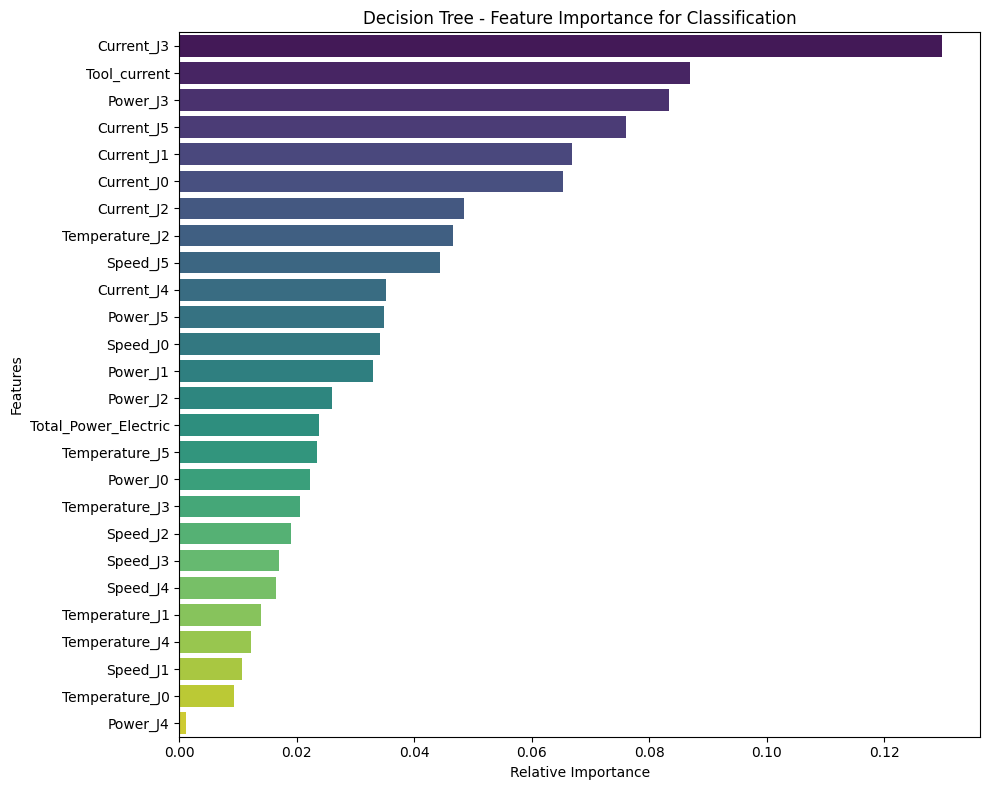

가장 중요한 피처 상위 5개:
     Feature  Importance
  Current_J3    0.129819
Tool_current    0.086990
    Power_J3    0.083358
  Current_J5    0.075963
  Current_J1    0.066824


In [11]:
# 1. Feature Importance 추출 (Pipeline의 'dt' 모델에서 추출)
best_dt = selected_model.named_steps['dt']
feature_importances = best_dt.feature_importances_

importance_df = pd.DataFrame({
    'Feature': input_cols,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# 2. 시각화
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Decision Tree - Feature Importance for Classification')
plt.xlabel('Relative Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# 가장 중요한 상위 5개 피처 출력
print("가장 중요한 피처 상위 5개:")
print(importance_df.head(5).to_string(index=False))

### Cell 9: 의사결정나무 시각화

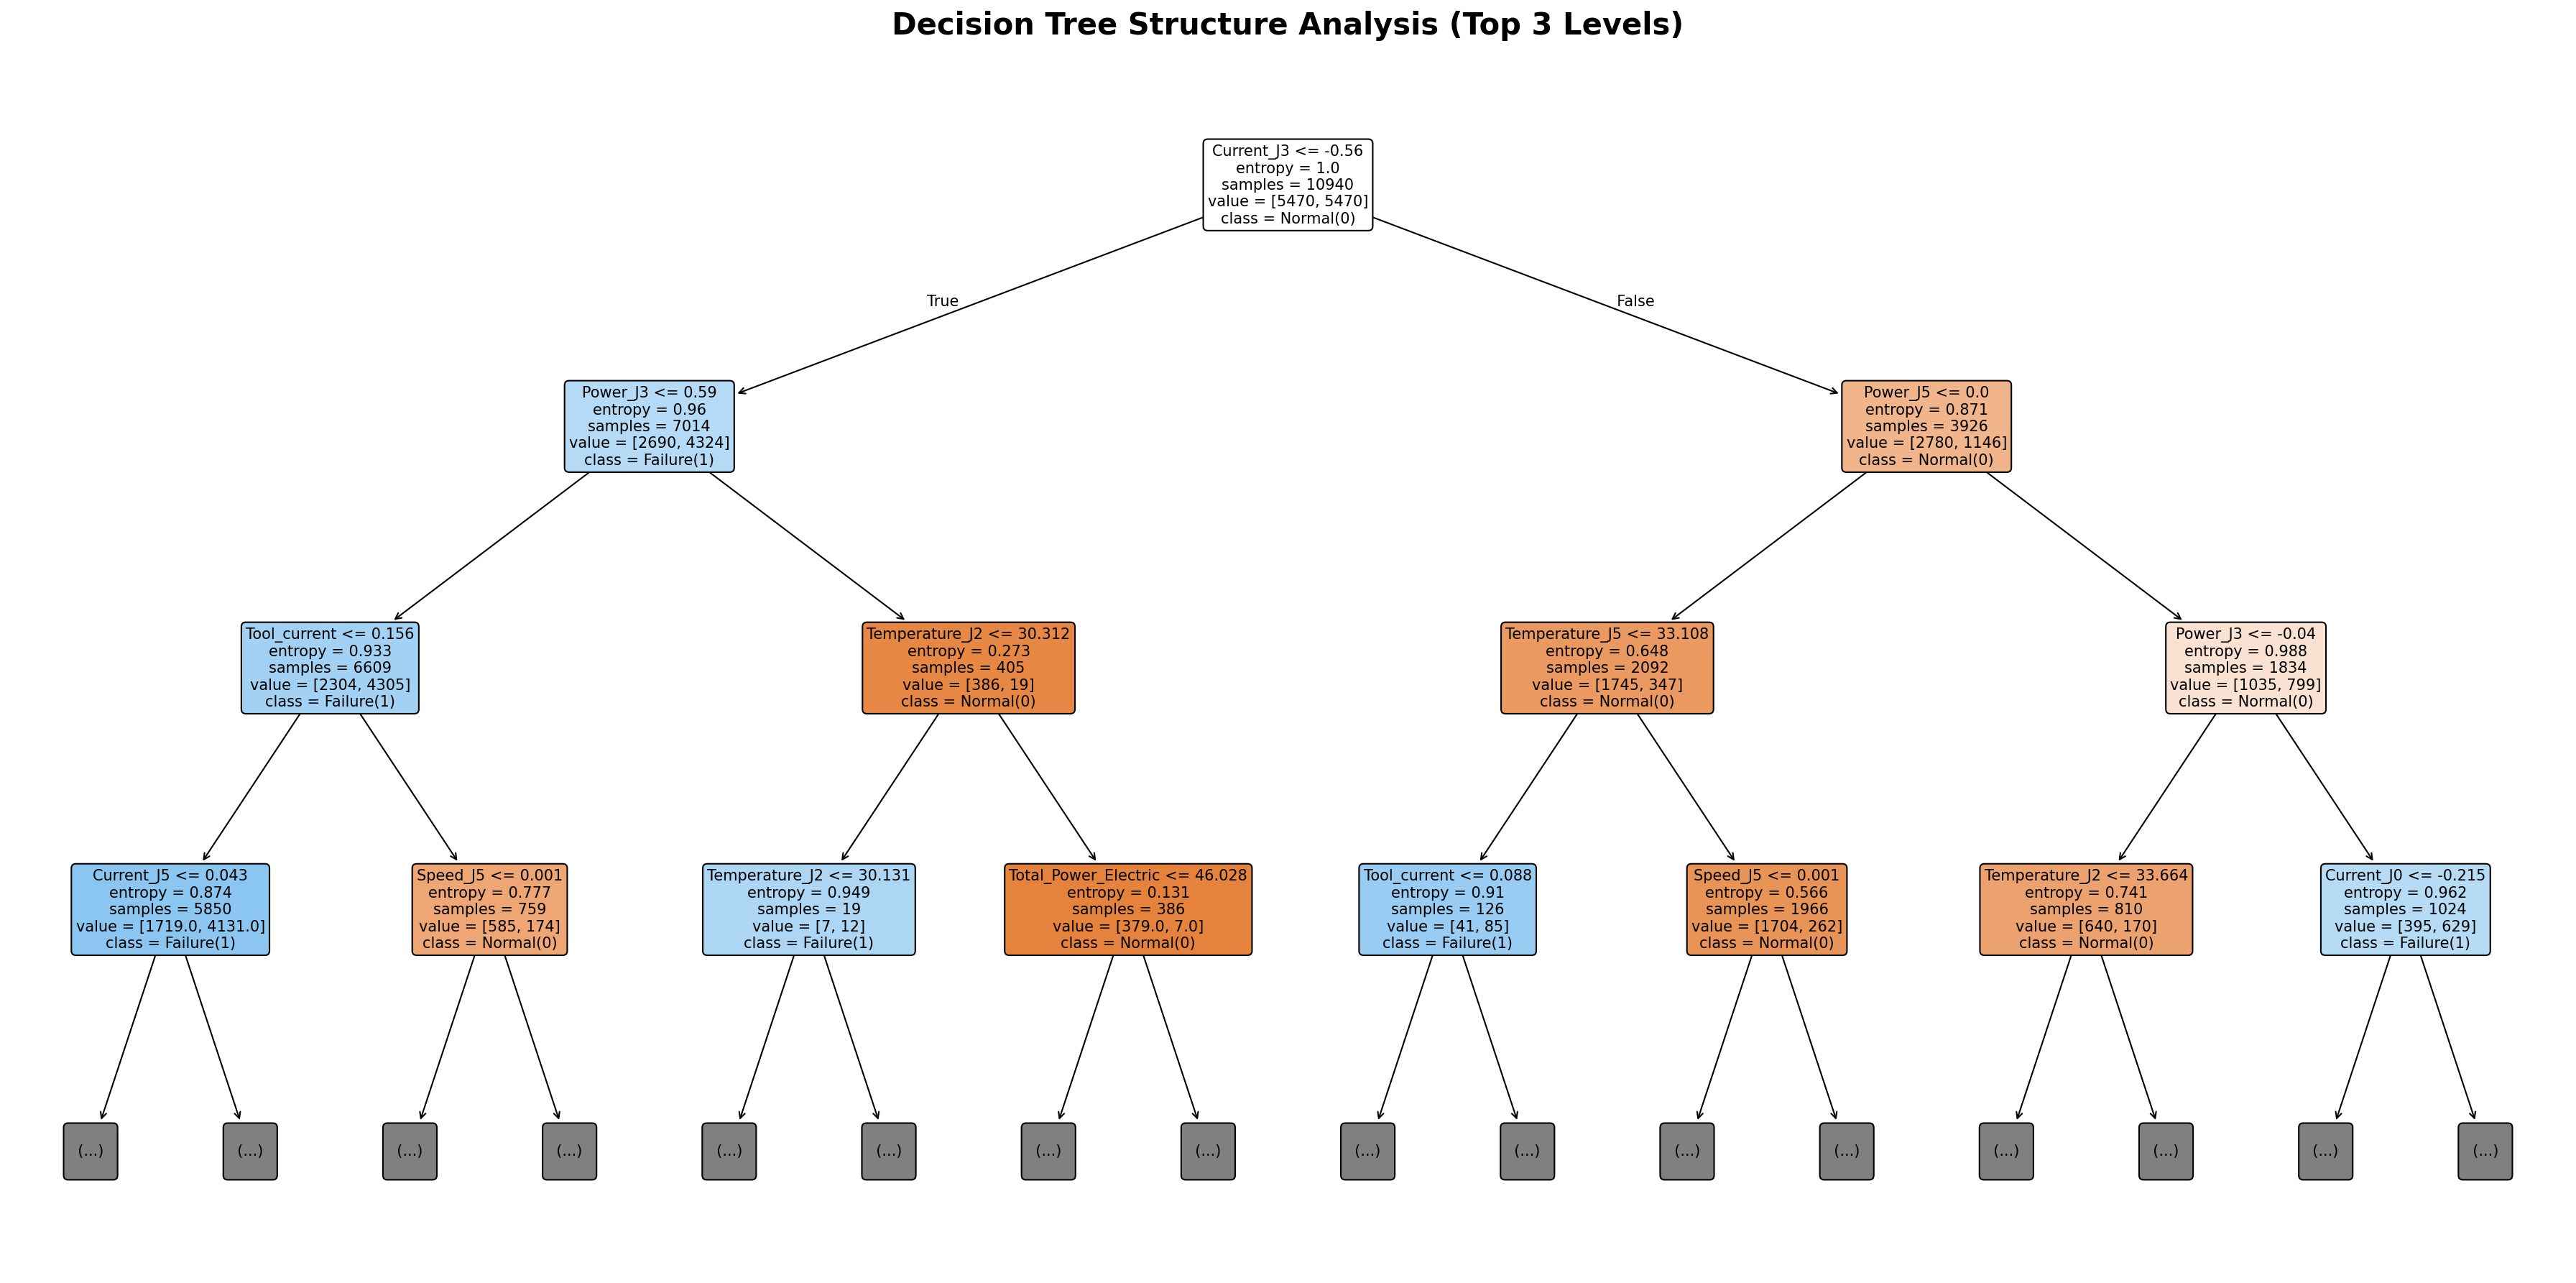

In [12]:
# 1. 그래프 크기 설정
plt.figure(figsize=(24, 12), dpi=150)

# 2. plot_tree 실행 (분기 과정을 시각화하여 비선형 경계를 어떻게 자르는지 확인)
plot_tree(
    best_dt, 
    max_depth=3,               # 가독성을 위해 상위 3단계까지만 시각화
    feature_names=input_cols,  # 실제 변수명 표기
    class_names=['Normal(0)', 'Failure(1)'], # 클래스명 표기
    filled=True,               # 클래스에 따라 색상 채우기
    rounded=True,              # 노드 박스 모서리 둥글게
    fontsize=10                # 글자 크기
)

# 3. 타이틀 설정 및 시각화
plt.title("Decision Tree Structure Analysis (Top 3 Levels)", fontsize=20, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

--- Decision Tree: 결정 경계 시각화 (PCA) ---


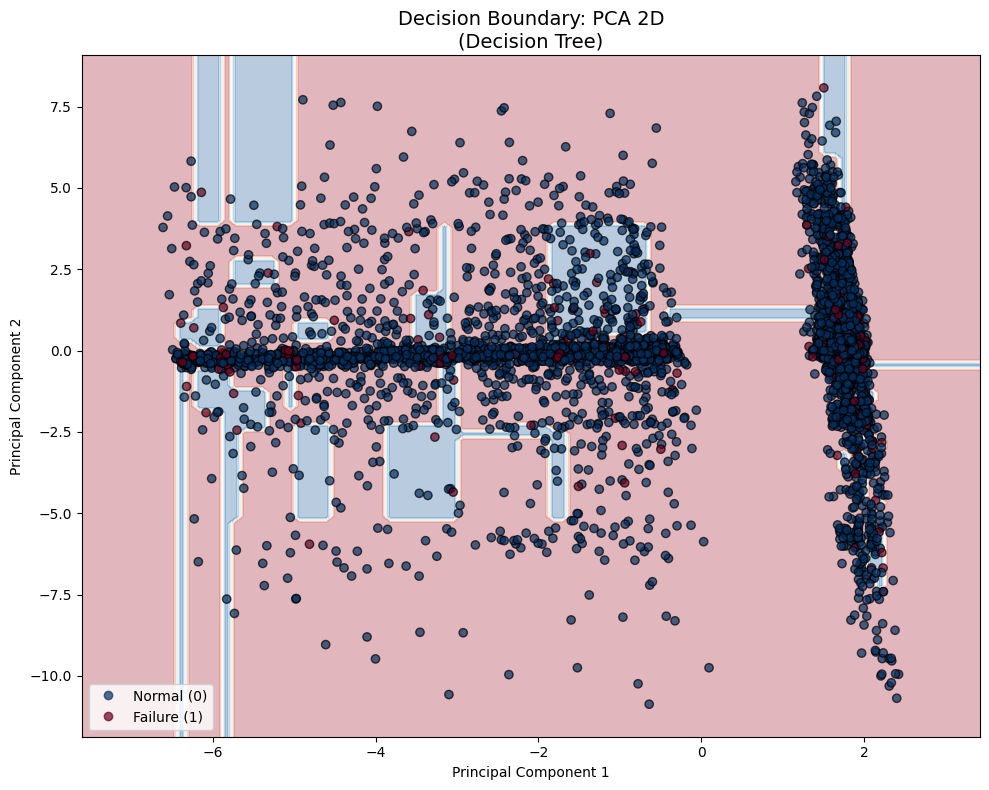

In [19]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import DecisionBoundaryDisplay

print("--- Decision Tree: 결정 경계 시각화 (PCA) ---")

fig, axes = plt.subplots(figsize=(10, 8))
scatter_kwargs = {'edgecolors': 'k', 'alpha': 0.7}

# 1위 모델의 파라미터 딕셔너리 재구성 (접두사 'dt__' 제거)
dt_params = {k.replace('dt__', ''): v for k, v in selected_params.items()}

# ==========================================
# 1. PCA 2D 결정 경계 (SVM 시각화 결과와 직접적인 형태 비교용)
# ==========================================
scaler_pca = StandardScaler()
X_train_scaled_pca = scaler_pca.fit_transform(X_train)
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled_pca)

model_pca = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('dt', DecisionTreeClassifier(**dt_params, random_state=42, class_weight='balanced'))
])
model_pca.fit(X_train_pca, y_train)

DecisionBoundaryDisplay.from_estimator(
    model_pca, X_train_pca, response_method="predict", cmap=plt.cm.RdBu, alpha=0.3, ax=axes
)
scatter1 = axes.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap=plt.cm.RdBu_r, **scatter_kwargs)
axes.set_title('Decision Boundary: PCA 2D\n(Decision Tree)', fontsize=14)
axes.set_xlabel('Principal Component 1')
axes.set_ylabel('Principal Component 2')
axes.legend(handles=scatter1.legend_elements()[0], labels=['Normal (0)', 'Failure (1)'], loc='lower left')

plt.tight_layout()
plt.show()